# Notebook 4: Data Distribution

**Sprint 2: Statistics & Mathematics for AI/ML Engineers**

---

## What is a Data Distribution?

A distribution shows **how the values of a variable are spread out**: which values occur often, which occur rarely, and what shape the data forms when plotted.

**Analogy:** If you measure the heights of 1,000 people and draw a histogram, most people fall near the average and very few are extremely tall or short. That shape is the distribution.

**Why it matters in AI/ML:** Many algorithms assume a particular shape (for example, Linear Regression assumes normally distributed errors). Knowing the shape tells us which statistics, scaling methods and tests to use.

**Topics covered:** Normal, Uniform, Gaussian, Symmetric, Left Skew, Right Skew, Kurtosis, Empirical Rule.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

## 1. Normal Distribution

**Definition:** The normal distribution is a symmetric, bell-shaped distribution where most values are near the mean and the probability falls off equally on both sides. It is fully described by two numbers: the mean (μ) and the standard deviation (σ).

**Formula (probability density function):**

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \; e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

**Numerical Example:** Heights of adults: mean μ = 170 cm, σ = 10 cm.
- Most people are between 160 and 180 cm (within 1σ).
- A person with height 185 cm has Z = (185 - 170) / 10 = **1.5**, meaning 1.5 standard deviations above the mean.

**Business Example:** Daily sales of a large store, delivery times, and measurement errors in a factory often follow a bell curve, so managers can plan stock and quality limits.

**AI/ML Example:** Linear Regression assumes normally distributed errors. Neural network weights are often initialized from a normal distribution. Many features are transformed (log, Box-Cox) to look more normal.

Mean  : 170.06
Median: 170.13
Std   : 9.96


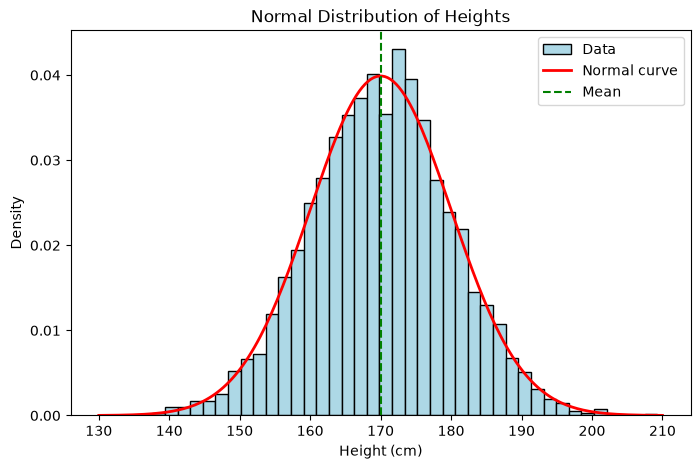

In [2]:
mu, sigma = 170, 10
heights = np.random.normal(loc=mu, scale=sigma, size=5000)

print("Mean  :", round(np.mean(heights), 2))
print("Median:", round(np.median(heights), 2))
print("Std   :", round(np.std(heights), 2))

# Histogram with the theoretical normal curve
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)
plt.figure(figsize=(8, 5))
plt.hist(heights, bins=40, density=True, color="lightblue", edgecolor="black", label="Data")
plt.plot(x, stats.norm.pdf(x, mu, sigma), "r-", linewidth=2, label="Normal curve")
plt.axvline(mu, color="green", linestyle="--", label="Mean")
plt.title("Normal Distribution of Heights")
plt.xlabel("Height (cm)")
plt.ylabel("Density")
plt.legend()
plt.show()

**Explanation:** We generate 5,000 heights from a normal distribution, then draw a histogram and the theoretical bell curve on top. `density=True` scales the histogram so it can be compared with the curve.

**Interpretation:** The histogram follows the red curve closely. The mean and median are almost equal, which is a sign of a symmetric distribution. Most values are around 170 and very few are below 140 or above 200.

## 2. Gaussian Distribution

**Definition:** "Gaussian" is another name for the normal distribution, named after the mathematician Carl Friedrich Gauss. The two terms mean the same thing. The special case with μ = 0 and σ = 1 is called the **Standard Normal Distribution**.

**Formula (Z-score to convert any normal value into standard normal):**

$$Z = \frac{x - \mu}{\sigma}$$

**Numerical Example:** Exam marks have μ = 60 and σ = 10. A student scoring 80 has Z = (80 - 60) / 10 = **2**. About 97.7% of students scored below this student.

**Business Example:** A company converts different test scores (out of different totals) into Z-scores to compare candidates fairly.

**AI/ML Example:** **Standardization** (StandardScaler) converts a feature into a Z-score so it has mean 0 and std 1. **Gaussian Naive Bayes** assumes each feature is Gaussian within a class. Gaussian noise is added to images for data augmentation.

In [3]:
marks = np.random.normal(loc=60, scale=10, size=1000)

# Convert to Z-scores
z_scores = (marks - marks.mean()) / marks.std()
print("Z-score mean:", round(z_scores.mean(), 4))
print("Z-score std :", round(z_scores.std(), 4))

# Z-score of a student scoring 80
z = (80 - 60) / 10
print("\nZ-score of 80:", z)
print("Percentage of students below 80:", round(stats.norm.cdf(z) * 100, 2), "%")

Z-score mean: 0.0
Z-score std : 1.0

Z-score of 80: 2.0
Percentage of students below 80: 97.72 %


**Explanation:** We convert all marks into Z-scores by subtracting the mean and dividing by the standard deviation. `stats.norm.cdf(z)` gives the probability of getting a value below z.

**Interpretation:** After standardization the mean is about 0 and the standard deviation is 1. A Z-score of 2 means the student is 2 standard deviations above average, better than about 97.7% of students. Z-scores let us compare values from different scales.

## 3. Uniform Distribution

**Definition:** In a uniform distribution every value in a range [a, b] is **equally likely**. The graph is a flat rectangle.

**Formula:**

$$f(x) = \frac{1}{b - a} \quad (a \le x \le b)$$

$$Mean = \frac{a + b}{2} \qquad Variance = \frac{(b - a)^2}{12}$$

**Numerical Example:** A bus arrives every 10 minutes, and you arrive at a random time, so your waiting time is uniform between 0 and 10.
- Mean wait = (0 + 10) / 2 = **5 minutes**
- P(wait < 3 min) = 3 / 10 = **0.3**
- Variance = 10² / 12 = **8.33**

**Business Example:** A lottery draw or a random number generator, where every outcome has the same chance.

**AI/ML Example:** Random initialization of weights (Xavier uniform), random train-test splitting, and random hyperparameter search all use uniform random numbers.

Mean     : 4.97 | Theory: 5.0
Variance : 8.25 | Theory: 8.33
P(wait < 3): 0.3 | Theory: 0.3


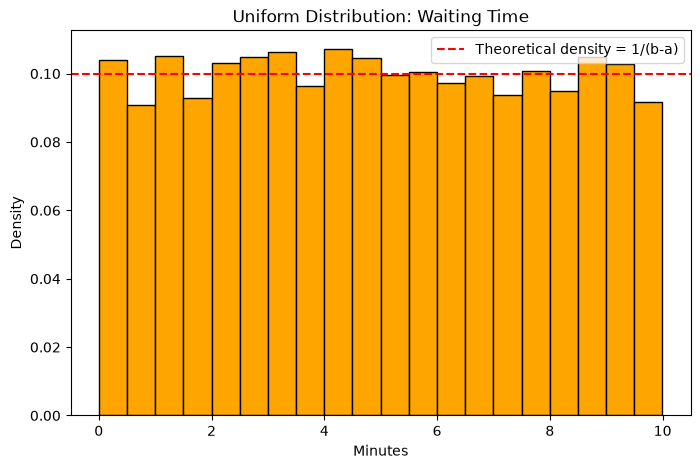

In [4]:
a, b = 0, 10
wait_times = np.random.uniform(low=a, high=b, size=5000)

print("Mean     :", round(wait_times.mean(), 2), "| Theory:", (a + b) / 2)
print("Variance :", round(wait_times.var(), 2), "| Theory:", round((b - a) ** 2 / 12, 2))
print("P(wait < 3):", round(np.mean(wait_times < 3), 3), "| Theory:", 3 / 10)

plt.figure(figsize=(8, 5))
plt.hist(wait_times, bins=20, density=True, color="orange", edgecolor="black")
plt.axhline(1 / (b - a), color="red", linestyle="--", label="Theoretical density = 1/(b-a)")
plt.title("Uniform Distribution: Waiting Time")
plt.xlabel("Minutes")
plt.ylabel("Density")
plt.legend()
plt.show()

**Explanation:** We generate 5,000 random waiting times between 0 and 10 minutes and compare the simulated mean, variance and probability with the theoretical values.

**Interpretation:** The histogram is roughly flat, which means every waiting time is equally likely. The simulated values are close to the theory (mean 5, variance 8.33, probability 0.3).

## 4. Symmetric Distribution

**Definition:** A distribution is symmetric if the left half is a mirror image of the right half around the center. In a symmetric distribution, **Mean = Median** (and Mode too for a single peak).

**Formula:** Skewness ≈ 0

**Numerical Example:** Data = 10, 20, 30, 40, 50. Mean = 30, Median = 30. Equal on both sides.

**Business Example:** The weights of packaged flour bags from a well-calibrated machine are symmetric around the target weight.

**AI/ML Example:** Symmetric features usually work well with models that assume normality (Linear Regression, LDA) and need little transformation.

## 5. Right Skew (Positive Skew)

**Definition:** The distribution has a long tail on the **right** side. Most values are small and a few are very large. Here **Mean > Median > Mode**.

**Formula (skewness):**

$$Skewness = \frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^3$$

Skewness > 0 means right skew.

**Numerical Example:** Data = 1, 2, 2, 3, 3, 3, 4, 4, 20
Mean = 42 / 9 = **4.67**, Median = **3**. The value 20 pulls the mean to the right.

**Business Example:** Income, house prices and customer spending are right-skewed: many ordinary values and a few very high ones.

**AI/ML Example:** Right-skewed features are often transformed with **log** or **square root** before training so models are not dominated by extreme values.

## 6. Left Skew (Negative Skew)

**Definition:** The distribution has a long tail on the **left** side. Most values are large and a few are very small. Here **Mean < Median < Mode**.

**Formula:** Skewness < 0 means left skew.

**Numerical Example:** Exam marks = 35, 70, 75, 78, 80, 80, 82, 85, 90
Mean = 675 / 9 = **75**, Median = **80**. The low mark 35 pulls the mean to the left.

**Business Example:** Scores in an easy exam, or the age at retirement: most values are high, with a few very low ones.

**AI/ML Example:** Left-skewed features can be reflected and then log-transformed (or use a power transform) to make them more symmetric.

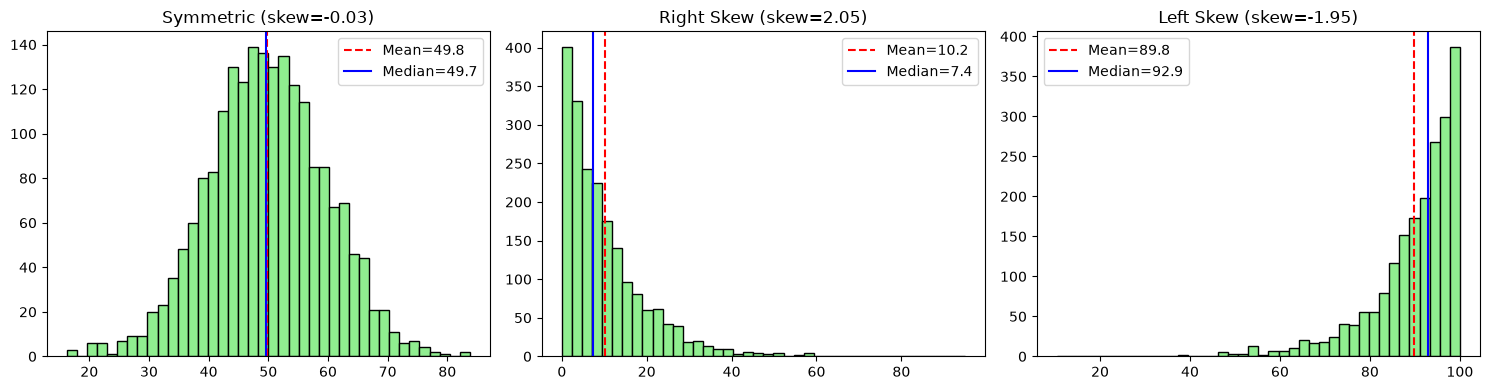

Right data -> Mean: 4.67 | Median: 3.0 | Skew: 2.34
Left data  -> Mean: 75.0 | Median: 80.0 | Skew: -1.9


In [5]:
symmetric = np.random.normal(50, 10, 2000)
right_skew = np.random.exponential(scale=10, size=2000)
left_skew = 100 - np.random.exponential(scale=10, size=2000)

datasets = {"Symmetric": symmetric, "Right Skew": right_skew, "Left Skew": left_skew}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, d) in zip(axes, datasets.items()):
    ax.hist(d, bins=40, color="lightgreen", edgecolor="black")
    ax.axvline(np.mean(d), color="red", linestyle="--", label=f"Mean={np.mean(d):.1f}")
    ax.axvline(np.median(d), color="blue", linestyle="-", label=f"Median={np.median(d):.1f}")
    ax.set_title(f"{name} (skew={stats.skew(d):.2f})")
    ax.legend()
plt.tight_layout()
plt.show()

# Small numerical examples from the markdown
right_data = [1, 2, 2, 3, 3, 3, 4, 4, 20]
left_data = [35, 70, 75, 78, 80, 80, 82, 85, 90]
print("Right data -> Mean:", round(np.mean(right_data), 2), "| Median:", np.median(right_data), "| Skew:", round(stats.skew(right_data), 2))
print("Left data  -> Mean:", round(np.mean(left_data), 2), "| Median:", np.median(left_data), "| Skew:", round(stats.skew(left_data), 2))

**Explanation:** We create symmetric, right-skewed and left-skewed data and plot each one with its mean (red) and median (blue). `stats.skew()` calculates the skewness value.

**Interpretation:**
- Symmetric: skewness is near 0 and mean ≈ median.
- Right skew: skewness is positive and mean > median (the tail goes right).
- Left skew: skewness is negative and mean < median (the tail goes left).

| Shape | Skewness | Mean vs Median | Typical fix |
|---|---|---|---|
| Symmetric | ≈ 0 | Mean = Median | None needed |
| Right skew | > 0 | Mean > Median | Log / sqrt transform |
| Left skew | < 0 | Mean < Median | Reflect + log, or power transform |

**Rule of thumb:** |skewness| < 0.5 is roughly symmetric, 0.5 to 1 is moderately skewed, and above 1 is highly skewed.

## 7. Kurtosis

**Definition:** Kurtosis measures how **heavy the tails** of a distribution are (how many extreme values exist) compared to a normal distribution. It is often described as "tailedness" and not just "peakedness".

**Formula (excess kurtosis):**

$$Kurtosis = \frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^4 - 3$$

(The "- 3" makes a normal distribution have excess kurtosis = 0.)

| Type | Excess kurtosis | Meaning |
|---|---|---|
| Mesokurtic | ≈ 0 | Normal-like tails |
| Leptokurtic | > 0 | Heavy tails, more outliers |
| Platykurtic | < 0 | Light tails, fewer outliers |

**Numerical Example:** Uniform distribution has excess kurtosis = -1.2 (very light tails, no extreme values). Normal has 0. A heavy-tailed distribution like Laplace has +3.

**Business Example:** Stock returns are leptokurtic: extreme gains and losses happen more often than a normal distribution predicts, so risk models must account for it.

**AI/ML Example:** High kurtosis warns of many outliers in a feature, which can hurt models like Linear Regression and k-Means. It guides the choice of outlier treatment and scaling.

Normal  (mesokurtic)  : 0.0
Uniform (platykurtic) : -1.2
Laplace (leptokurtic) : 3.39


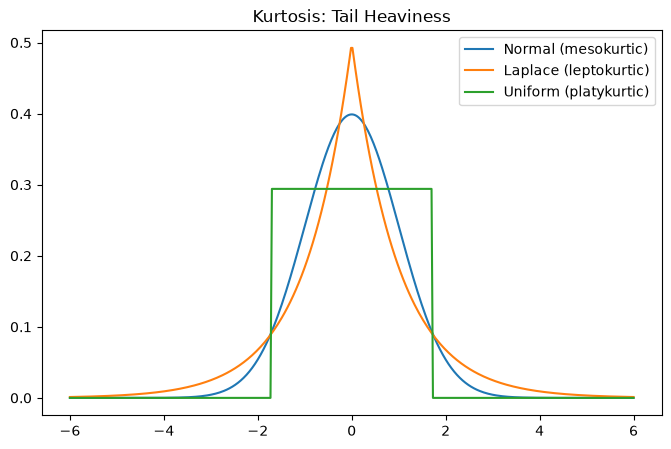

In [6]:
normal_data = np.random.normal(0, 1, 10000)
uniform_data = np.random.uniform(-1.7, 1.7, 10000)   # similar spread, light tails
heavy_data = np.random.laplace(0, 1, 10000)           # heavy tails

print("Normal  (mesokurtic)  :", round(stats.kurtosis(normal_data), 2))
print("Uniform (platykurtic) :", round(stats.kurtosis(uniform_data), 2))
print("Laplace (leptokurtic) :", round(stats.kurtosis(heavy_data), 2))

x = np.linspace(-6, 6, 400)
plt.figure(figsize=(8, 5))
plt.plot(x, stats.norm.pdf(x, 0, 1), label="Normal (mesokurtic)")
plt.plot(x, stats.laplace.pdf(x, 0, 1), label="Laplace (leptokurtic)")
plt.plot(x, stats.uniform.pdf(x, -1.7, 3.4), label="Uniform (platykurtic)")
plt.title("Kurtosis: Tail Heaviness")
plt.legend()
plt.show()

**Explanation:** We generate three datasets and calculate their excess kurtosis with `stats.kurtosis()` (SciPy gives excess kurtosis by default).

**Interpretation:** Normal is close to 0, uniform is about -1.2 (light tails), and Laplace is about +3 (heavy tails, a sharper peak and more extreme values). Higher kurtosis means a higher chance of outliers.

## 8. Empirical Rule (68-95-99.7 Rule)

**Definition:** For a normal distribution, almost all data lies within 3 standard deviations of the mean:
- **68%** of values lie within 1σ of the mean
- **95%** of values lie within 2σ
- **99.7%** of values lie within 3σ

**Formula:**

$$P(\mu - k\sigma \le X \le \mu + k\sigma) \approx 68\%,\ 95\%,\ 99.7\% \quad \text{for } k = 1, 2, 3$$

**Numerical Example:** Heights with μ = 170 and σ = 10:
- 68% are between 160 and 180
- 95% are between 150 and 190
- 99.7% are between 140 and 200

**Business Example:** Quality control (Six Sigma): if a bottle's fill volume is normal, anything beyond 3σ from the target is very rare and signals a machine problem.

**AI/ML Example:** The **Z-score outlier method** flags values beyond 3σ as outliers. The rule also helps set thresholds for anomaly detection.

Within 1 std (160 to 180): 68.27%  | Theory: 68.27%
Within 2 std (150 to 190): 95.36%  | Theory: 95.45%
Within 3 std (140 to 200): 99.74%  | Theory: 99.73%


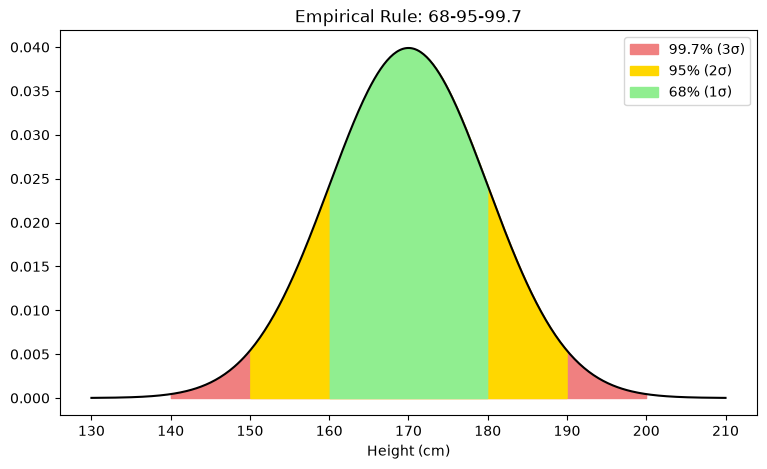

In [8]:
mu, sigma = 170, 10
data = np.random.normal(mu, sigma, 100000)

for k in [1, 2, 3]:
    lower, upper = mu - k * sigma, mu + k * sigma
    within = np.mean((data >= lower) & (data <= upper)) * 100
    theory = (stats.norm.cdf(k) - stats.norm.cdf(-k)) * 100
    print(f"Within {k} std ({lower} to {upper}): {within:.2f}%  | Theory: {theory:.2f}%")

# Visualization
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 400)
y = stats.norm.pdf(x, mu, sigma)
plt.figure(figsize=(9, 5))
plt.plot(x, y, "k")
plt.fill_between(x, y, where=(x >= mu - 3 * sigma) & (x <= mu + 3 * sigma), color="lightcoral", label="99.7% (3σ)")
plt.fill_between(x, y, where=(x >= mu - 2 * sigma) & (x <= mu + 2 * sigma), color="gold", label="95% (2σ)")
plt.fill_between(x, y, where=(x >= mu - sigma) & (x <= mu + sigma), color="lightgreen", label="68% (1σ)")
plt.title("Empirical Rule: 68-95-99.7")
plt.xlabel("Height (cm)")
plt.legend()
plt.show()

**Explanation:** We generate 100,000 normal values and count the percentage inside 1σ, 2σ and 3σ. We also compute the exact theoretical values using the normal CDF.

**Interpretation:** The simulated results are about 68.3%, 95.4% and 99.7%, matching the rule. So if a value is more than 3σ from the mean (for example, a height above 200 cm here), it is very unusual and could be an outlier. **This rule works only for (approximately) normal data.**

## Summary

| Distribution / Concept | Shape | Key point | Used for |
|---|---|---|---|
| Normal / Gaussian | Bell, symmetric | Defined by μ and σ | Heights, errors, many ML assumptions |
| Uniform | Flat | All values equally likely | Random numbers, weight initialization |
| Symmetric | Mirror image | Mean = Median | Models assuming normality |
| Right skew | Tail on right | Mean > Median | Income, prices (use log transform) |
| Left skew | Tail on left | Mean < Median | Easy exam scores |
| Kurtosis | Tail heaviness | Normal = 0 (excess) | Outlier risk |
| Empirical rule | 68-95-99.7 | Only for normal data | Z-score outlier detection |

## Advantages
- Knowing the distribution helps us pick the right statistics (mean or median) and the right model
- Helps decide on transformations (log, standardization)
- The normal distribution is well studied, and many tests and formulas are built on it
- The empirical rule gives quick probability estimates without calculation

## Limitations
- Real-world data is rarely perfectly normal
- The empirical rule is wrong for skewed or heavy-tailed data
- Skewness and kurtosis are sensitive to outliers
- Small samples can give a misleading shape
- Kurtosis is often misread as "peakedness", but it mainly measures tails